In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import ast
import warnings
warnings.filterwarnings("ignore")


In [14]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

df = pd.read_csv("/content/drive/MyDrive/gridlock_flipkart/enriched_violations.csv")
df["created_dt"] = pd.to_datetime(df["created_dt"], utc=True)
df["date"]       = pd.to_datetime(df["date"])

print(f"Loaded {len(df):,} records | {df['date'].min().date()} → {df['date'].max().date()}")
print("=" * 60)

Loaded 115,400 records | 2023-11-09 → 2024-03-29



[CELL 1] Daily volume trend...


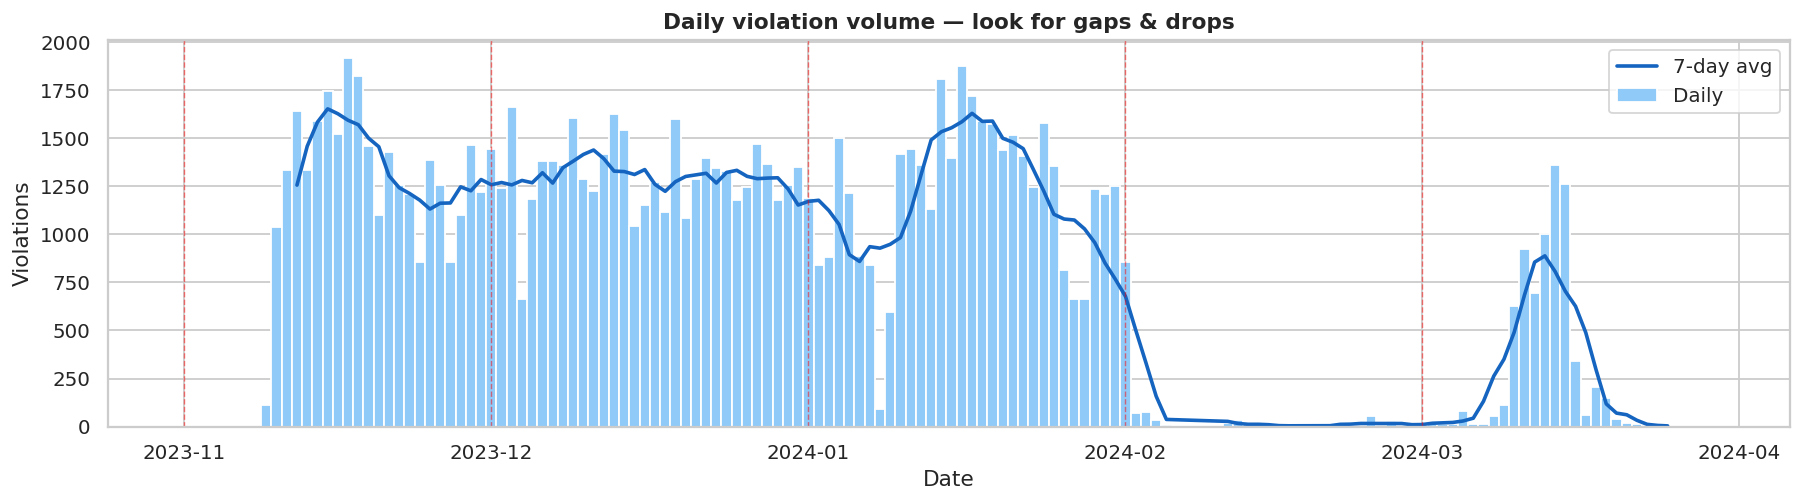

   → Saved: cell1_daily_trend.png


In [15]:
print("\n[CELL 1] Daily volume trend...")

daily = df.groupby("date").size().reset_index(name="count")
daily["rolling7"] = daily["count"].rolling(7, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(daily["date"], daily["count"], color="#90CAF9", width=1, label="Daily")
ax.plot(daily["date"], daily["rolling7"], color="#1565C0", lw=2, label="7-day avg")
ax.set_title("Daily violation volume — look for gaps & drops", fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Violations")
ax.legend()

# mark month boundaries
for m in range(11, 16):
    mo = 2023 + (m - 1) // 12
    mn = ((m - 1) % 12) + 1
    try:
        ax.axvline(pd.Timestamp(f"{mo}-{mn:02d}-01"), color="red",
                   ls="--", lw=0.8, alpha=0.5)
    except Exception:
        pass

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/gridlock_flipkart/cell1_daily_trend.png")
plt.show()
print("   → Saved: cell1_daily_trend.png")



[CELL 2] Hourly distribution by month...


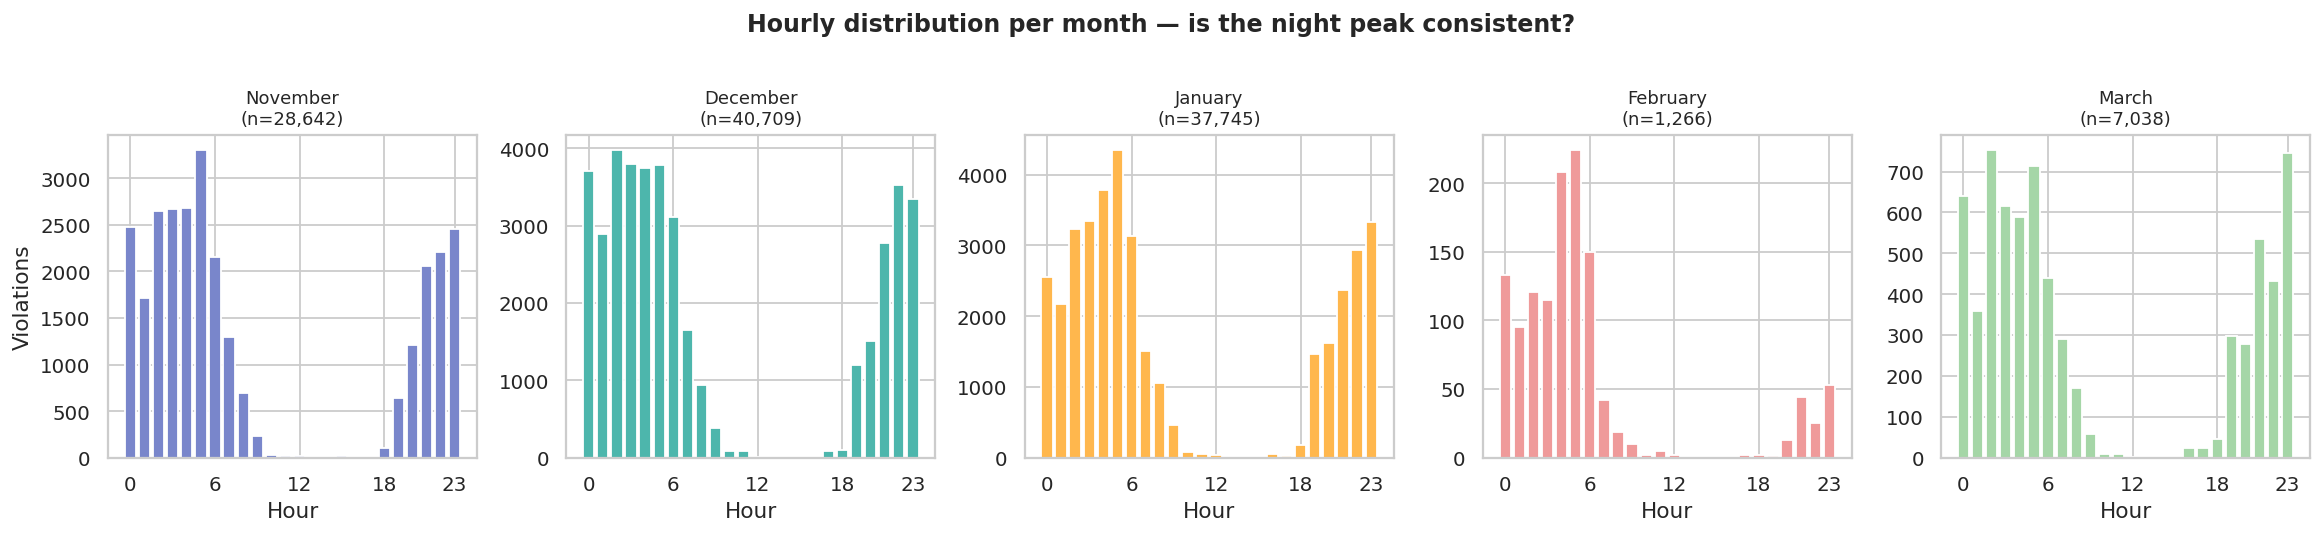

   → Saved: cell2_hourly_by_month.png


In [16]:
print("\n[CELL 2] Hourly distribution by month...")

months_order = ["November", "December", "January", "February", "March"]
month_data   = df[df["month_name"].isin(months_order)]

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)
colors = ["#7986CB","#4DB6AC","#FFB74D","#EF9A9A","#A5D6A7"]

for i, (mo, color) in enumerate(zip(months_order, colors)):
    sub = month_data[month_data["month_name"] == mo]
    hr  = sub.groupby("hour").size()
    axes[i].bar(hr.index, hr.values, color=color, width=0.8)
    axes[i].set_title(f"{mo}\n(n={len(sub):,})", fontsize=10)
    axes[i].set_xlabel("Hour")
    if i == 0:
        axes[i].set_ylabel("Violations")
    axes[i].set_xticks([0, 6, 12, 18, 23])

fig.suptitle("Hourly distribution per month — is the night peak consistent?",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/gridlock_flipkart/cell2_hourly_by_month.png")
plt.show()
print("   → Saved: cell2_hourly_by_month.png")


[CELL 3] Hour × Day heatmap...


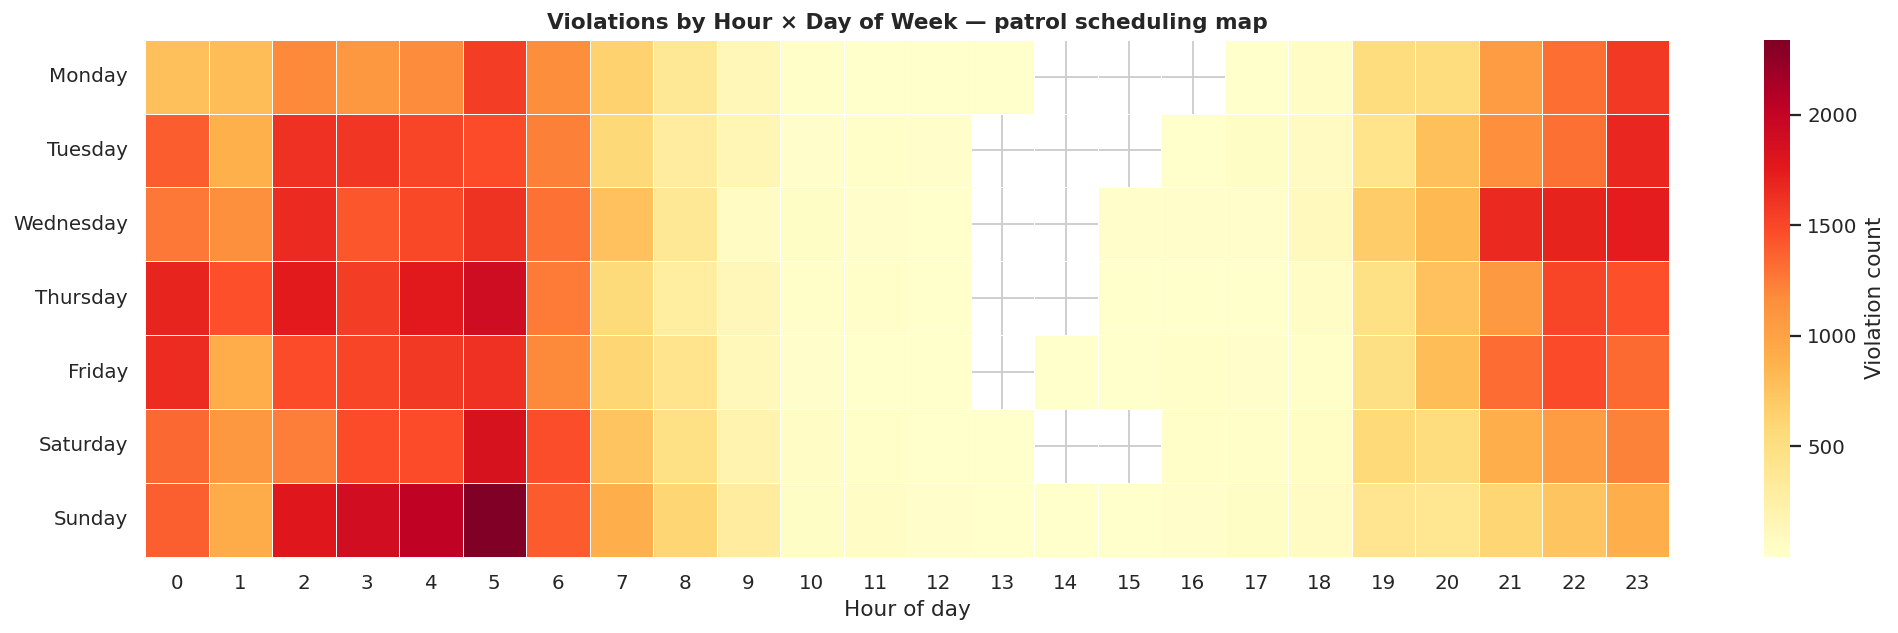

   → Saved: cell3_hour_day_heatmap.png


In [17]:
print("\n[CELL 3] Hour × Day heatmap...")

pivot = df.pivot_table(index="day_name", columns="hour",
                       values="id", aggfunc="count")
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
pivot = pivot.reindex(day_order)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, cmap="YlOrRd", ax=ax, linewidths=0.3,
            cbar_kws={"label": "Violation count"})
ax.set_title("Violations by Hour × Day of Week — patrol scheduling map",
             fontweight="bold")
ax.set_xlabel("Hour of day")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/gridlock_flipkart/cell3_hour_day_heatmap.png")
plt.show()
print("   → Saved: cell3_hour_day_heatmap.png")



[CELL 4] Station volume vs severity...


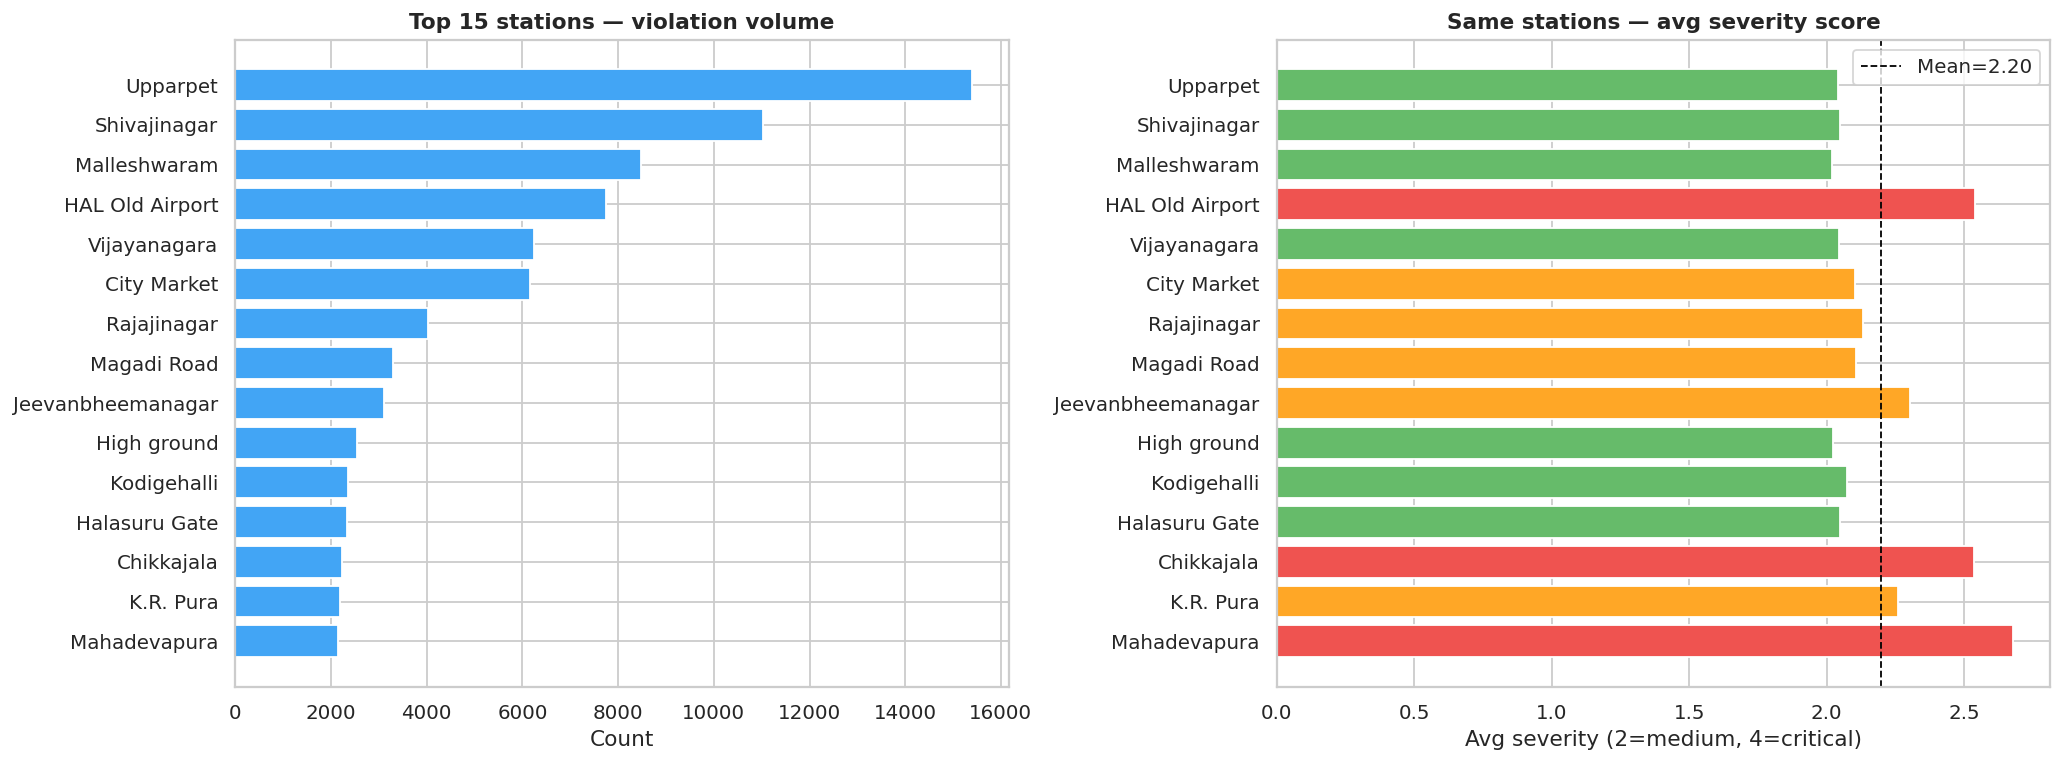

   → Saved: cell4_station_volume_severity.png


In [18]:
print("\n[CELL 4] Station volume vs severity...")

station = df.groupby("police_station").agg(
    count        = ("id", "count"),
    avg_severity = ("severity_score", "mean"),
    avg_veh_wt   = ("vehicle_weight", "mean"),
    junction_pct = ("at_junction", "mean")
).reset_index().sort_values("count", ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: volume
axes[0].barh(station["police_station"][::-1],
             station["count"][::-1], color="#42A5F5")
axes[0].set_title("Top 15 stations — violation volume", fontweight="bold")
axes[0].set_xlabel("Count")

# Right: avg severity (same stations)
bar_colors = ["#EF5350" if s >= 2.5 else "#FFA726" if s >= 2.1
              else "#66BB6A" for s in station["avg_severity"][::-1]]
axes[1].barh(station["police_station"][::-1],
             station["avg_severity"][::-1], color=bar_colors)
axes[1].set_title("Same stations — avg severity score", fontweight="bold")
axes[1].set_xlabel("Avg severity (2=medium, 4=critical)")
axes[1].axvline(station["avg_severity"].mean(), color="black",
                ls="--", lw=1, label=f"Mean={station['avg_severity'].mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/gridlock_flipkart/cell4_station_volume_severity.png")
plt.show()
print("   → Saved: cell4_station_volume_severity.png")




[CELL 5] Spatial scatter coloured by severity...


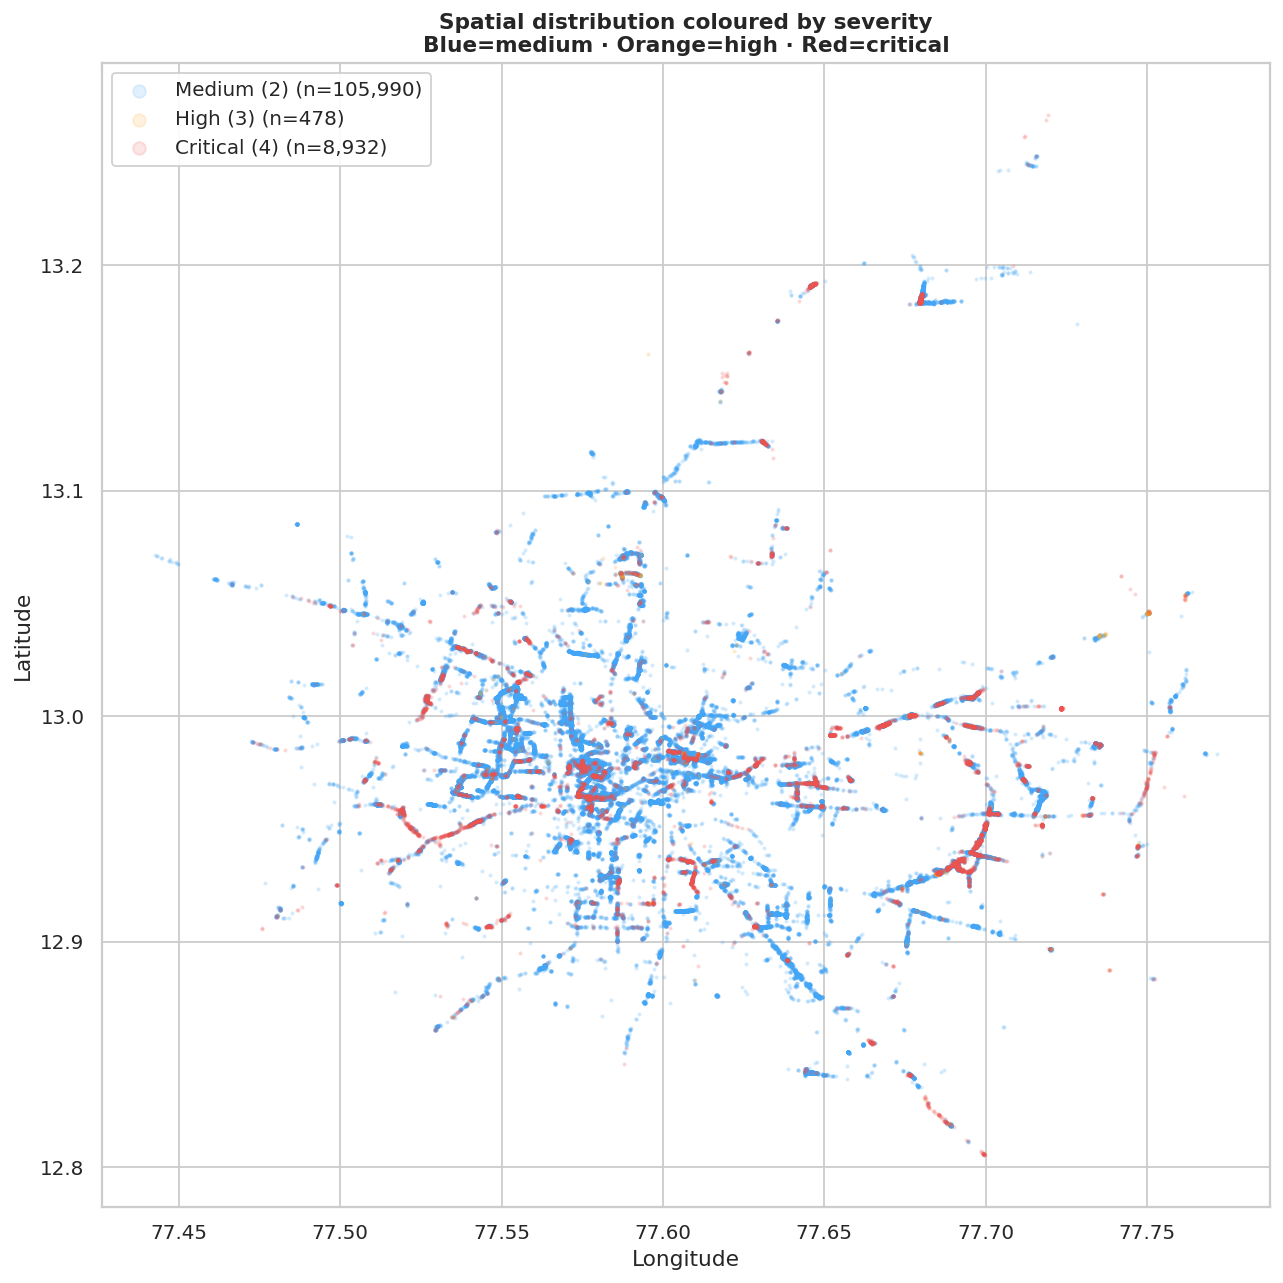

   → Saved: cell5_spatial_severity.png


In [20]:
print("\n[CELL 5] Spatial scatter coloured by severity...")

fig, ax = plt.subplots(figsize=(10, 10))
colors_sev = {2: "#42A5F5", 3: "#FFA726", 4: "#EF5350"}
labels_sev = {2: "Medium (2)", 3: "High (3)", 4: "Critical (4)"}

for sev in [2, 3, 4]:
    sub = df[df["severity_score"] == sev]
    ax.scatter(sub["longitude"], sub["latitude"],
               s=2, alpha=0.15, c=colors_sev[sev],
               label=f"{labels_sev[sev]} (n={len(sub):,})")

ax.set_title("Spatial distribution coloured by severity\n"
             "Blue=medium · Orange=high · Red=critical",
             fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(markerscale=5, framealpha=0.9)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/gridlock_flipkart/cell5_spatial_severity.png")
plt.show()
print("   → Saved: cell5_spatial_severity.png")



[CELL 6] Vehicle type × time bin...


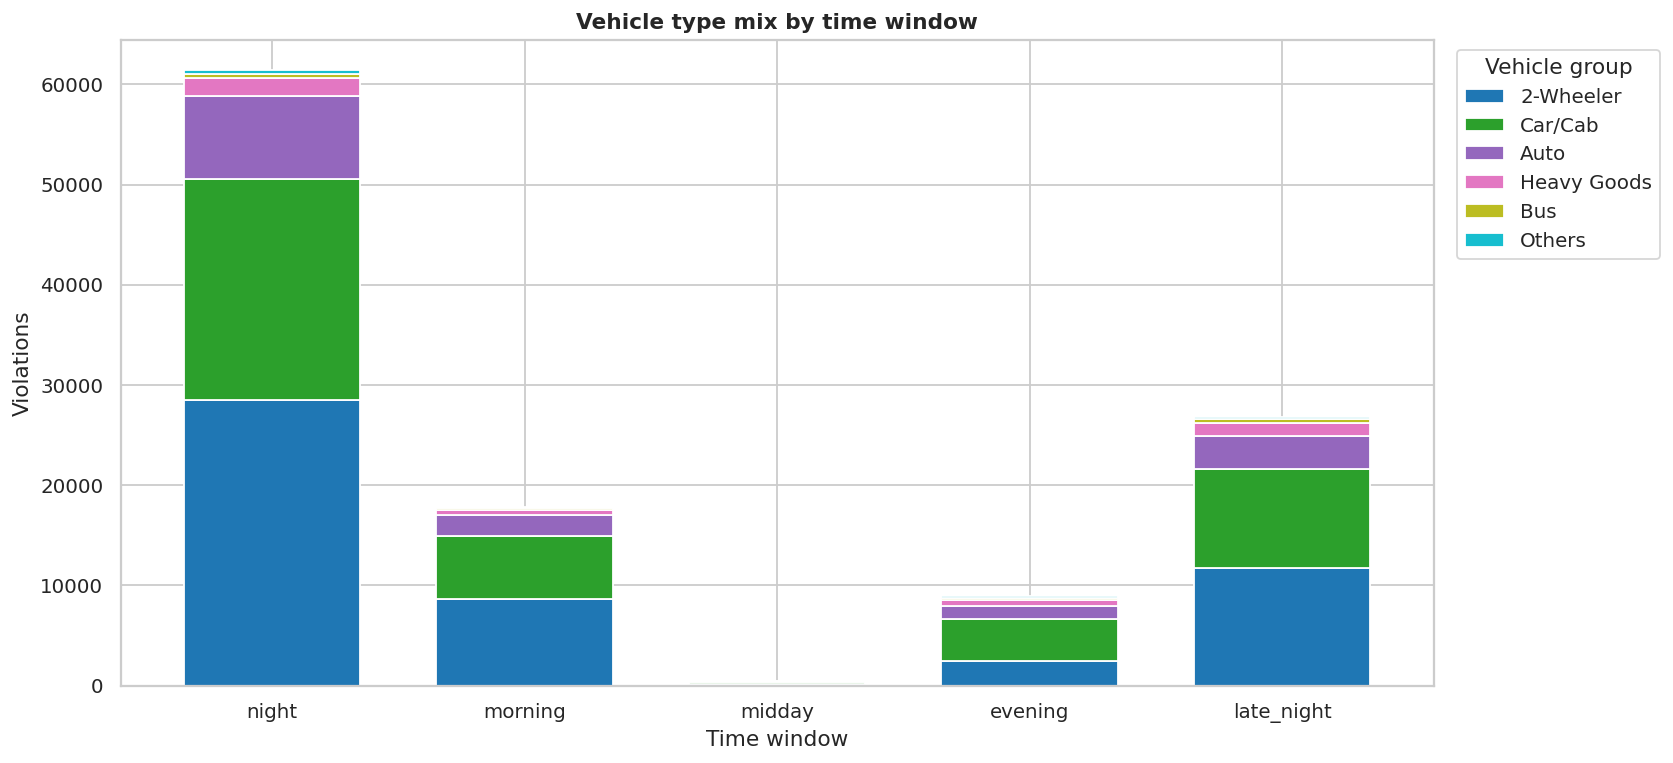

   → Saved: cell6_vehicle_time.png


In [21]:
print("\n[CELL 6] Vehicle type × time bin...")

# Group minor vehicles
def group_vehicle(v):
    if v in ["SCOOTER","MOTOR CYCLE","MOPED"]:           return "2-Wheeler"
    if v in ["CAR","JEEP","VAN","MAXI-CAB"]:             return "Car/Cab"
    if v in ["PASSENGER AUTO","GOODS AUTO"]:             return "Auto"
    if v in ["LGV","HGV","LORRY/GOODS VEHICLE",
             "MINI LORRY","TANKER","TRACTOR"]:           return "Heavy Goods"
    if v in ["PRIVATE BUS","BUS (BMTC/KSRTC)",
             "TOURIST BUS","SCHOOL VEHICLE",
             "FACTORY BUS"]:                             return "Bus"
    return "Others"

df["vehicle_group"] = df["vehicle_type"].apply(group_vehicle)

veh_time = (df.groupby(["time_bin","vehicle_group"])
              .size()
              .reset_index(name="count"))

time_order = ["night","morning","midday","evening","late_night"]
veh_order  = ["2-Wheeler","Car/Cab","Auto","Heavy Goods","Bus","Others"]
veh_time["time_bin"] = pd.Categorical(veh_time["time_bin"],
                                       categories=time_order, ordered=True)
veh_time = veh_time.sort_values("time_bin")

fig, ax = plt.subplots(figsize=(13, 6))
pivot_vt = veh_time.pivot(index="time_bin", columns="vehicle_group",
                           values="count").fillna(0)
pivot_vt = pivot_vt[veh_order]
pivot_vt.plot(kind="bar", ax=ax, stacked=True,
              colormap="tab10", width=0.7)
ax.set_title("Vehicle type mix by time window", fontweight="bold")
ax.set_xlabel("Time window")
ax.set_ylabel("Violations")
ax.set_xticklabels(time_order, rotation=0)
ax.legend(title="Vehicle group", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/gridlock_flipkart/cell6_vehicle_time.png")
plt.show()
print("   → Saved: cell6_vehicle_time.png")


[CELL 7] Junction vs non-junction comparison...


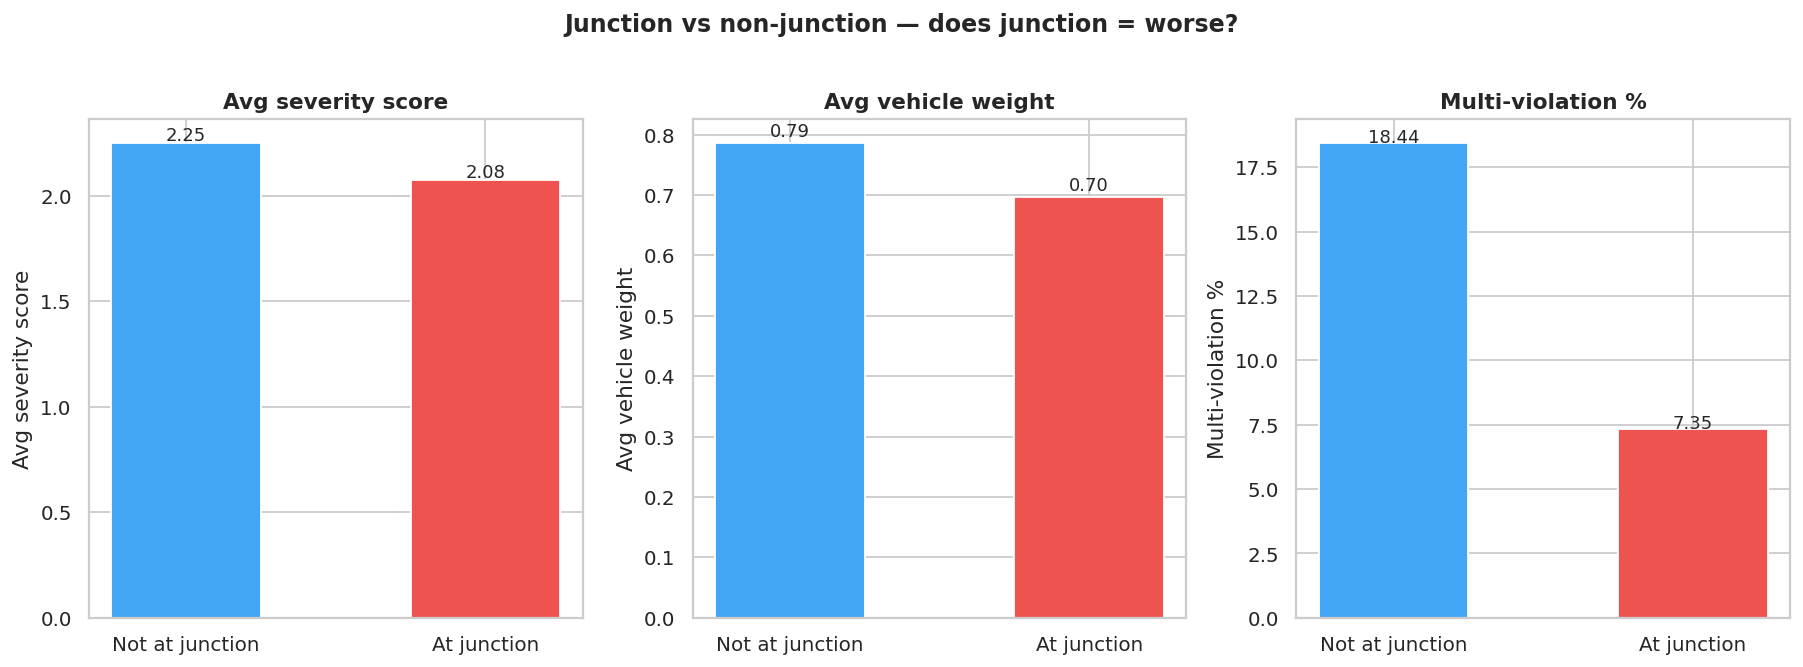

   → Saved: cell7_junction_comparison.png


In [22]:
print("\n[CELL 7] Junction vs non-junction comparison...")

junc_compare = df.groupby("at_junction").agg(
    count        = ("id", "count"),
    avg_severity = ("severity_score", "mean"),
    avg_veh_wt   = ("vehicle_weight", "mean"),
    multi_viol   = ("violation_count", lambda x: (x > 1).mean() * 100)
).reset_index()
junc_compare["label"] = junc_compare["at_junction"].map(
    {0: "Not at junction", 1: "At junction"})

metrics  = ["avg_severity","avg_veh_wt","multi_viol"]
titles   = ["Avg severity score","Avg vehicle weight","Multi-violation %"]
colors_j = ["#42A5F5","#EF5350"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, (m, t) in enumerate(zip(metrics, titles)):
    axes[i].bar(junc_compare["label"], junc_compare[m],
                color=colors_j, width=0.5)
    axes[i].set_title(t, fontweight="bold")
    axes[i].set_ylabel(t)
    for bar, val in zip(axes[i].patches, junc_compare[m]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f"{val:.2f}", ha="center", fontsize=10)

fig.suptitle("Junction vs non-junction — does junction = worse?",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/gridlock_flipkart/cell7_junction_comparison.png")
plt.show()
print("   → Saved: cell7_junction_comparison.png")



[CELL 8] Persistence proxy per junction...


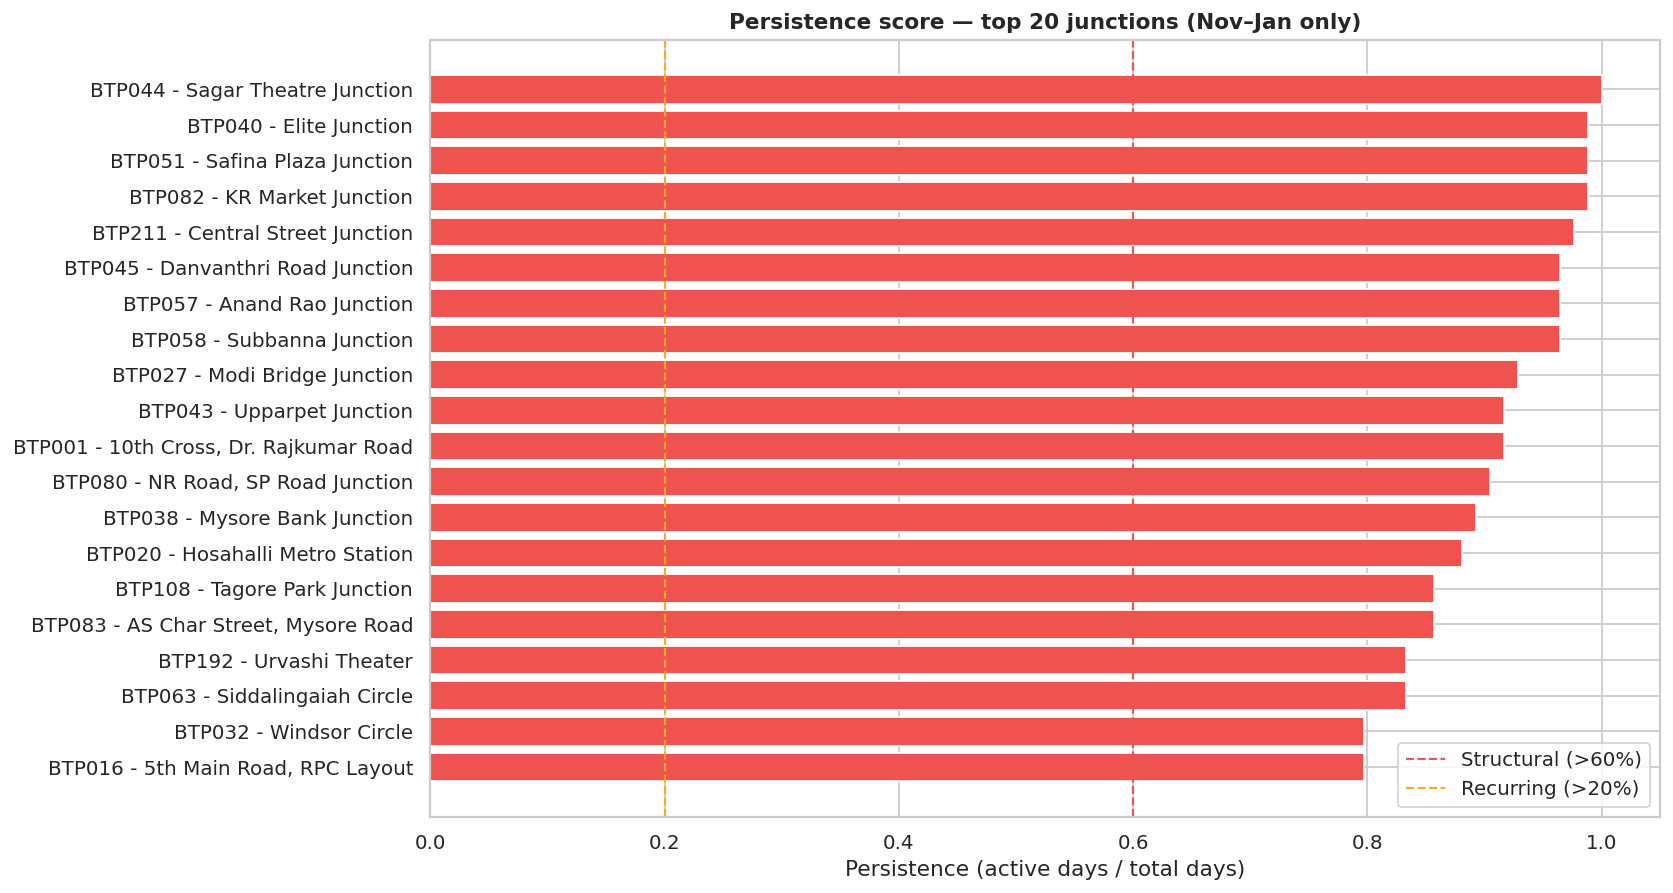

   → Saved: cell8_junction_persistence.png


In [23]:
print("\n[CELL 8] Persistence proxy per junction...")

# Use only Nov–Jan (complete months)
complete = df[df["month_name"].isin(["November","December","January"])]
total_days = complete["date"].nunique()

junc_persist = (complete[complete["junction_code"].notna()]
                .groupby("junction_code")["date"]
                .nunique()
                .reset_index(name="active_days"))
junc_persist["persistence"] = junc_persist["active_days"] / total_days
junc_persist["junction_name"] = junc_persist["junction_code"].map(
    df.groupby("junction_code")["junction_name"].first())

top20 = junc_persist.sort_values("persistence", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(13, 7))
bar_c = ["#EF5350" if p >= 0.6 else "#FFA726" if p >= 0.2
         else "#66BB6A" for p in top20["persistence"]]
ax.barh(top20["junction_name"][::-1],
        top20["persistence"][::-1], color=bar_c[::-1])
ax.axvline(0.6, color="#EF5350", ls="--", lw=1.2, label="Structural (>60%)")
ax.axvline(0.2, color="#FFA726", ls="--", lw=1.2, label="Recurring (>20%)")
ax.set_title("Persistence score — top 20 junctions (Nov–Jan only)",
             fontweight="bold")
ax.set_xlabel("Persistence (active days / total days)")
ax.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/gridlock_flipkart/cell8_junction_persistence.png")
plt.show()
print("   → Saved: cell8_junction_persistence.png")



[CELL 9] Severity per violation type...


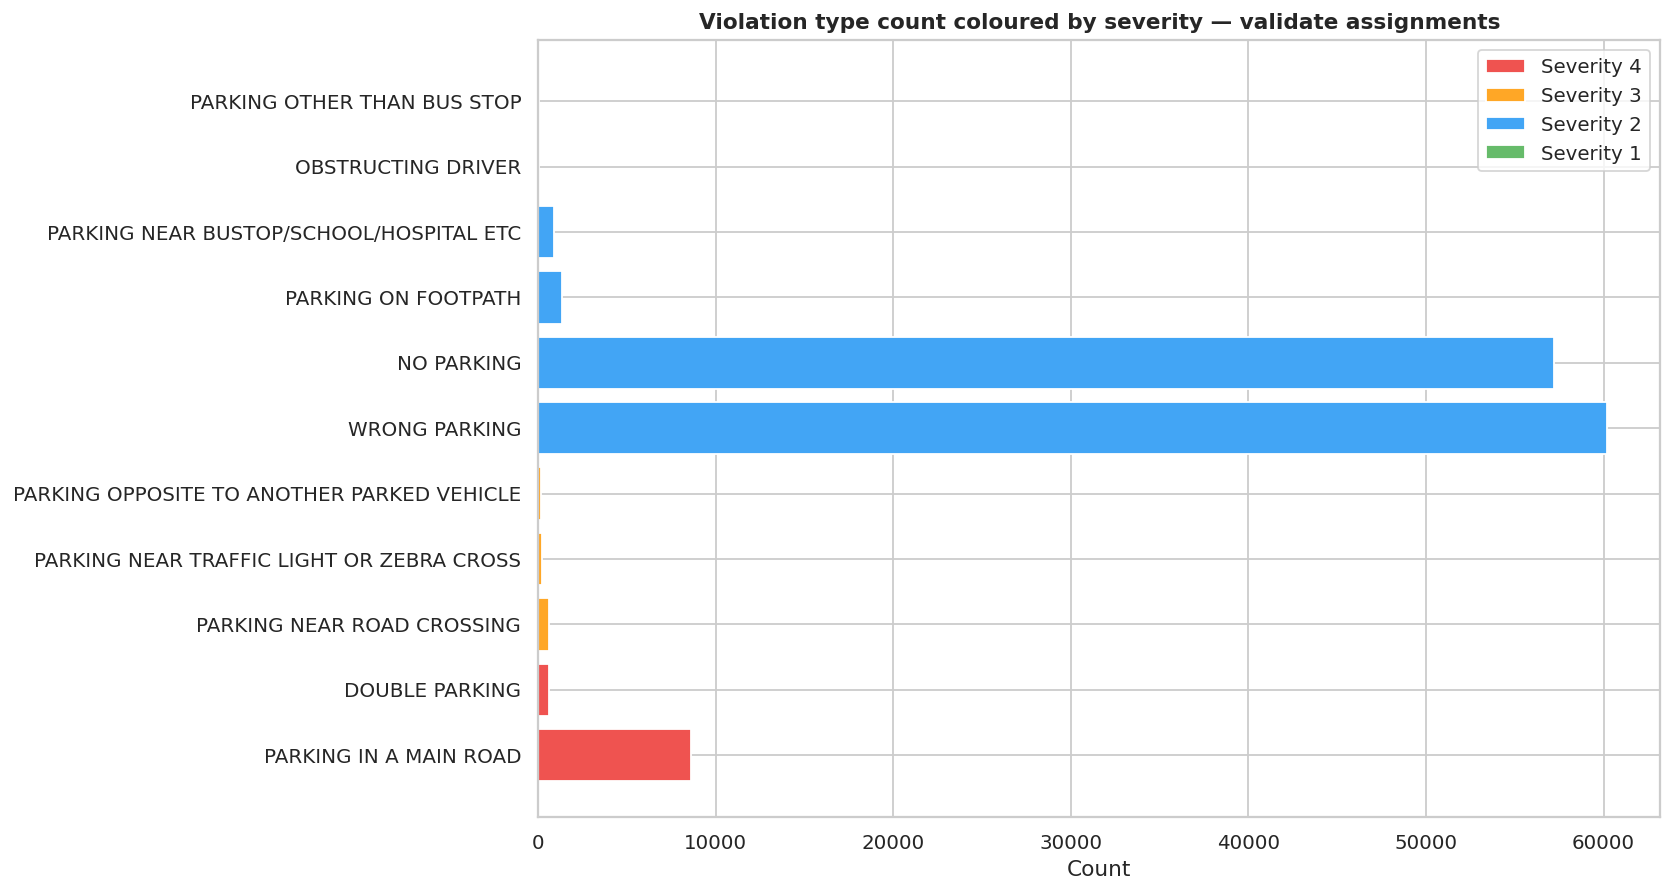

   → Saved: cell9_violation_severity.png


In [24]:
print("\n[CELL 9] Severity per violation type...")

SEVERITY_MAP = {
    "DOUBLE PARKING": 4, "PARKING IN A MAIN ROAD": 4,
    "PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS": 3,
    "PARKING NEAR ROAD CROSSING": 3,
    "PARKING OPPOSITE TO ANOTHER PARKED VEHICLE": 3,
    "NO PARKING": 2, "WRONG PARKING": 2,
    "PARKING ON FOOTPATH": 2,
    "PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC": 2,
    "PARKING OTHER THAN BUS STOP": 1,
    "OBSTRUCTING DRIVER": 2,
}

def parse_v(v):
    try: return ast.literal_eval(v)
    except: return []

rows = []
for _, row in df.iterrows():
    for v in parse_v(row["violation_type"]):
        s = SEVERITY_MAP.get(v, None)
        if s is not None:
            rows.append({"violation": v, "severity": s})

vdf = pd.DataFrame(rows)
counts = vdf.groupby(["violation","severity"]).size().reset_index(name="n")
counts = counts.sort_values(["severity","n"], ascending=[False, False])

fig, ax = plt.subplots(figsize=(13, 7))
colors_s = {4:"#EF5350", 3:"#FFA726", 2:"#42A5F5", 1:"#66BB6A"}
for _, row in counts.iterrows():
    ax.barh(row["violation"], row["n"],
            color=colors_s.get(row["severity"],"gray"))

from matplotlib.patches import Patch
legend_els = [Patch(facecolor=v, label=f"Severity {k}")
              for k,v in colors_s.items()]
ax.legend(handles=legend_els)
ax.set_title("Violation type count coloured by severity — validate assignments",
             fontweight="bold")
ax.set_xlabel("Count")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/gridlock_flipkart/cell9_violation_severity.png")
plt.show()
print("   → Saved: cell9_violation_severity.png")


In [25]:
print("\n[CELL 10] Data gap summary report...")
print("=" * 60)
print("DATA GAP REPORT")
print("=" * 60)

# Gap 1: Monthly completeness
monthly = df.groupby("month_name").size()
print("\nGAP 1 — Monthly data completeness:")
for mo in ["November","December","January","February","March"]:
    n = monthly.get(mo, 0)
    flag = " ← INCOMPLETE" if n < 5000 else ""
    print(f"  {mo:<12}: {n:>6,} records{flag}")

# Gap 2: Zero-violation days
all_dates = pd.date_range(df["date"].min(), df["date"].max())
recorded  = pd.to_datetime(df["date"].unique())
missing   = [d for d in all_dates if d not in recorded]
print(f"\nGAP 2 — Missing days (zero violations recorded): {len(missing)}")
if missing:
    print(f"  First 5: {[str(d.date()) for d in missing[:5]]}")

# Gap 3: Severity 1 missing
print(f"\nGAP 3 — Severity 1 violations: "
      f"{(df['severity_score']==1).sum()} "
      f"(low-impact violations may be under-represented)")

# Gap 4: Feb/Mar recommendation
print(f"\nGAP 4 — Persistence analysis recommendation:")
print(f"  Use Nov–Jan only ({complete['date'].nunique()} days)")
print(f"  Exclude Feb–Mar from persistence (data incomplete)")

# Gap 5: Spatial coverage
print(f"\nGAP 5 — Spatial coverage:")
print(f"  47.2% of violations have no junction code")
print(f"  These are mid-block violations — HDBSCAN handles them")
print(f"  but OSMnx road class needed for full impact scoring")

print("\n" + "=" * 60)
print("ALL GAPS IDENTIFIED. SAFE TO PROCEED TO STAGE 2 (HDBSCAN).")
print("=" * 60)


[CELL 10] Data gap summary report...
DATA GAP REPORT

GAP 1 — Monthly data completeness:
  November    : 28,642 records
  December    : 40,709 records
  January     : 37,745 records
  February    :  1,266 records ← INCOMPLETE
  March       :  7,038 records

GAP 2 — Missing days (zero violations recorded): 6
  First 5: ['2024-02-06', '2024-02-07', '2024-02-08', '2024-02-09', '2024-02-10']

GAP 3 — Severity 1 violations: 0 (low-impact violations may be under-represented)

GAP 4 — Persistence analysis recommendation:
  Use Nov–Jan only (84 days)
  Exclude Feb–Mar from persistence (data incomplete)

GAP 5 — Spatial coverage:
  47.2% of violations have no junction code
  These are mid-block violations — HDBSCAN handles them
  but OSMnx road class needed for full impact scoring

ALL GAPS IDENTIFIED. SAFE TO PROCEED TO STAGE 2 (HDBSCAN).


In [28]:
print(df.columns.tolist())

['id', 'latitude', 'longitude', 'police_station', 'junction_name', 'junction_code', 'at_junction', 'created_dt', 'date', 'hour', 'day_of_week', 'day_name', 'month', 'month_name', 'time_bin', 'is_weekend', 'violation_type', 'violations_list', 'violation_count', 'severity_score', 'is_parking_related', 'vehicle_type', 'vehicle_weight', 'validation_status', 'impact_proxy']


DATASET SHAPE
(115400, 24)

1. COORDINATE DUPLICATION ANALYSIS
Total records      : 115,400
Unique coordinates : 87,397
Duplicate rate     : 24.27%

Top 10 repeated coordinates:


,latitude,longitude,count
8064,12.930011,77.685171,46
10392,12.934068,77.689769,36
81314,13.034841,77.557343,31
10511,12.934368,77.690132,27
6921,12.926678,77.677832,27
10540,12.934467,77.690405,26
61259,12.987962,77.734140,24
153,12.839274,77.677801,23
71254,13.001045,77.549760,21
1666,12.891687,77.638497,21


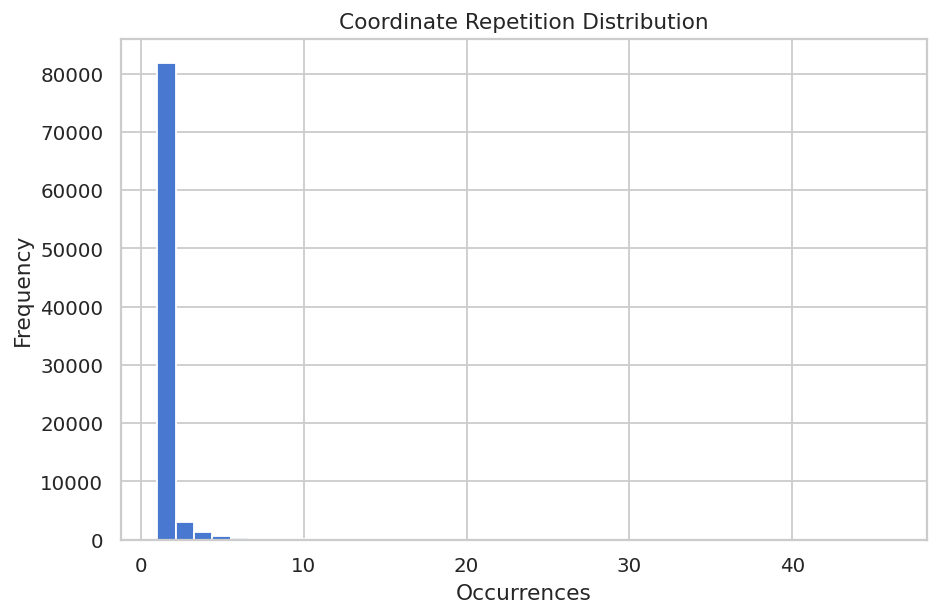


2. K-NEAREST NEIGHBOR DISTANCES
count    115400.000000
mean          0.000121
std           0.000458
min           0.000000
25%           0.000016
50%           0.000037
75%           0.000087
max           0.029828
dtype: float64


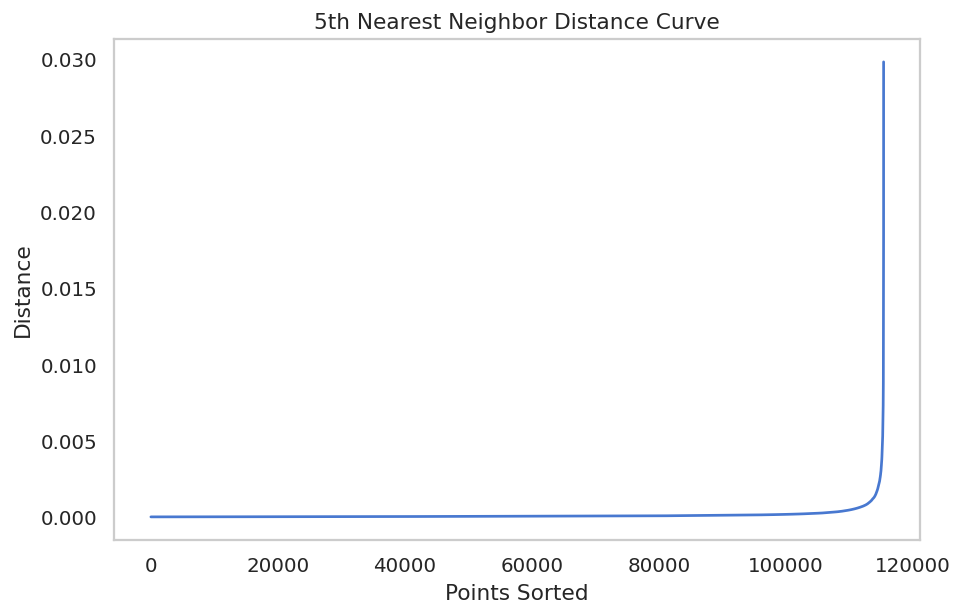


3. IMPACT PROXY ANALYSIS
count    115400.000000
mean          1.628966
std           1.086403
min           0.600000
25%           0.800000
50%           1.400000
75%           2.000000
max          10.000000
Name: impact_proxy, dtype: float64


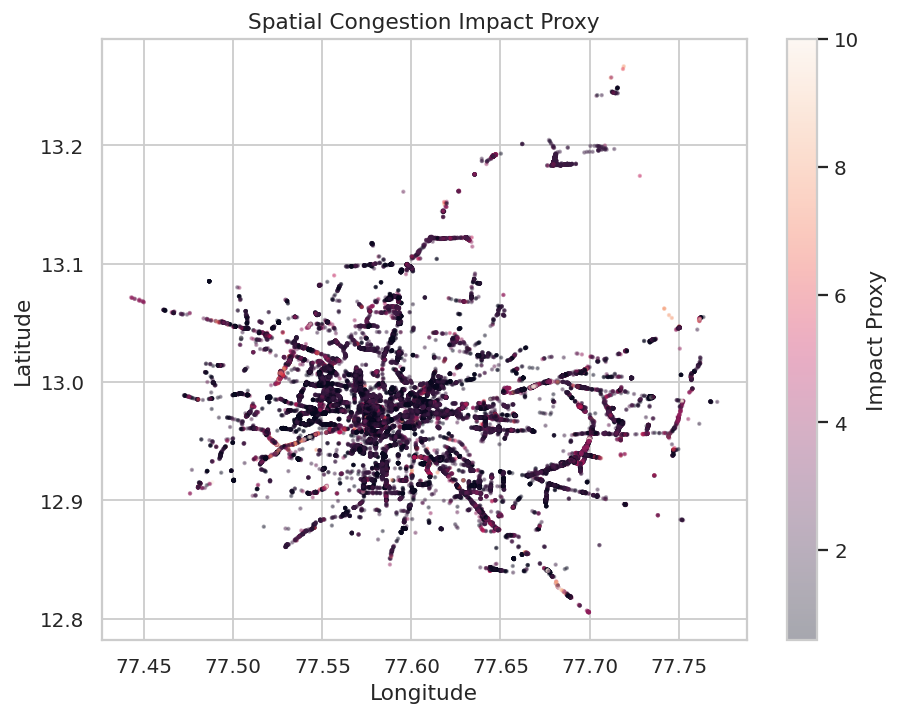


4. STATION CONCENTRATION
Top 10 stations contribute 58.95% of all violations


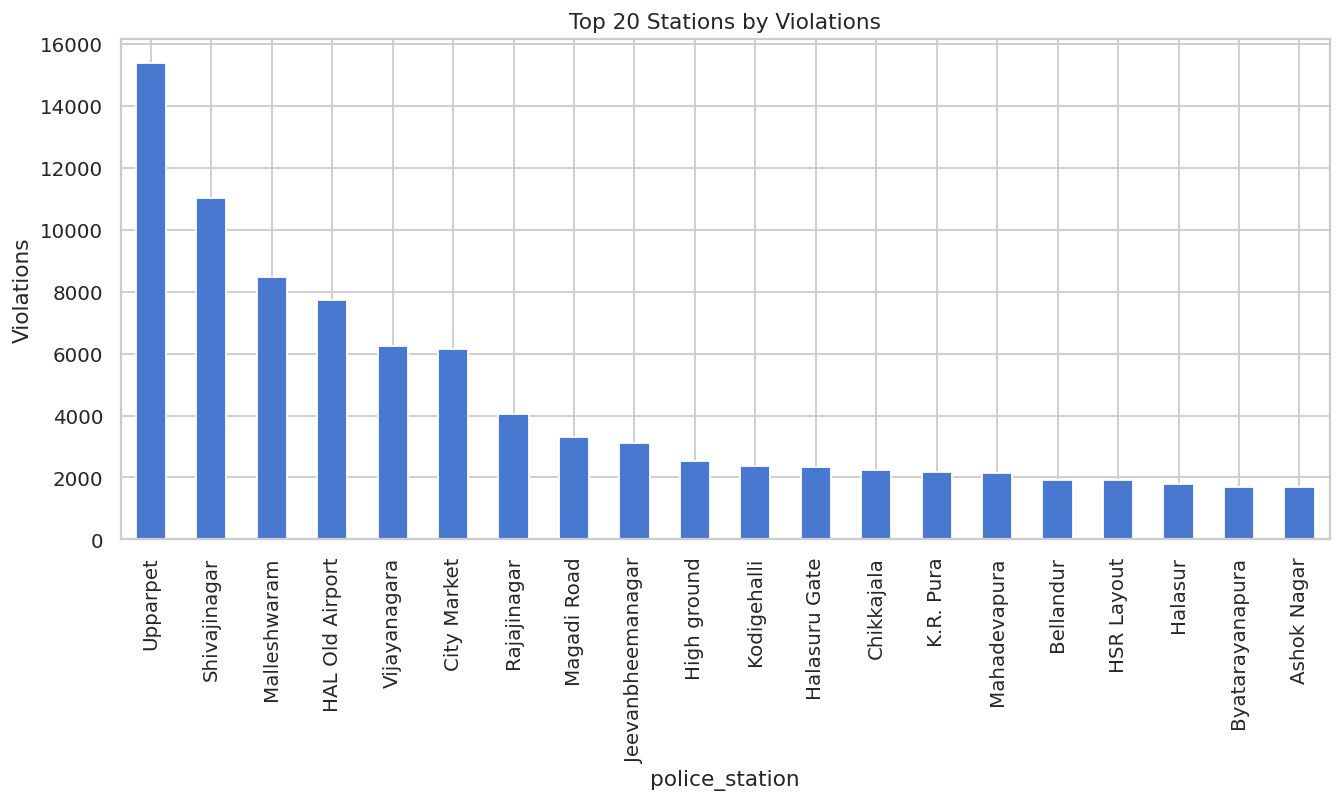


READY FOR HDBSCAN IF:
✓ No weird coordinate outliers
✓ Duplicate coordinates are reasonable
✓ K-distance curve shows clear elbow
✓ Station dominance not extreme (>70%)


In [30]:
# ==========================================================
# PRE-HDBSCAN SANITY CHECKS
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# Load enriched dataset
df = pd.read_csv("/content/drive/MyDrive/gridlock_flipkart/enriched_violations.csv")

print("="*60)
print("DATASET SHAPE")
print("="*60)
print(df.shape)

# ==========================================================
# 1. COORDINATE DUPLICATION ANALYSIS
# ==========================================================

print("\n" + "="*60)
print("1. COORDINATE DUPLICATION ANALYSIS")
print("="*60)

coord_counts = (
    df.groupby(["latitude", "longitude"])
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)

unique_coords = len(coord_counts)

dup_pct = (
    1 - unique_coords / len(df)
) * 100

print(f"Total records      : {len(df):,}")
print(f"Unique coordinates : {unique_coords:,}")
print(f"Duplicate rate     : {dup_pct:.2f}%")

print("\nTop 10 repeated coordinates:")
display(coord_counts.head(10))

# Plot coordinate frequency distribution
plt.figure(figsize=(8,5))
coord_counts["count"].clip(upper=100).hist(bins=40)
plt.title("Coordinate Repetition Distribution")
plt.xlabel("Occurrences")
plt.ylabel("Frequency")
plt.show()


# ==========================================================
# 2. K-NN DISTANCE ANALYSIS
# ==========================================================

print("\n" + "="*60)
print("2. K-NEAREST NEIGHBOR DISTANCES")
print("="*60)

coords = df[["latitude", "longitude"]].values

nbrs = NearestNeighbors(n_neighbors=5)
nbrs.fit(coords)

distances, _ = nbrs.kneighbors(coords)

kdist = np.sort(distances[:,4])

print(pd.Series(kdist).describe())

plt.figure(figsize=(8,5))
plt.plot(kdist)
plt.title("5th Nearest Neighbor Distance Curve")
plt.xlabel("Points Sorted")
plt.ylabel("Distance")
plt.grid()
plt.show()


# ==========================================================
# 3. IMPACT PROXY ANALYSIS
# ==========================================================

print("\n" + "="*60)
print("3. IMPACT PROXY ANALYSIS")
print("="*60)

df["impact_proxy"] = (
    df["severity_score"] *
    df["vehicle_weight"]
)

print(df["impact_proxy"].describe())

plt.figure(figsize=(8,6))

plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["impact_proxy"],
    s=2,
    alpha=0.35
)

plt.colorbar(label="Impact Proxy")
plt.title("Spatial Congestion Impact Proxy")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


# ==========================================================
# 4. STATION ENFORCEMENT CONCENTRATION
# ==========================================================

print("\n" + "="*60)
print("4. STATION CONCENTRATION")
print("="*60)

# Replace with actual column if different
station_col = "police_station"

if station_col in df.columns:

    station_counts = (
        df[station_col]
        .value_counts()
    )

    top10_pct = (
        station_counts.head(10).sum()
        / len(df)
    ) * 100

    print(f"Top 10 stations contribute {top10_pct:.2f}% of all violations")

    plt.figure(figsize=(12,5))
    station_counts.head(20).plot(kind="bar")
    plt.title("Top 20 Stations by Violations")
    plt.ylabel("Violations")
    plt.show()

else:
    print(
        f"Column '{station_col}' not found."
    )

# ==========================================================
# FINAL RECOMMENDATION
# ==========================================================

print("\n" + "="*60)
print("READY FOR HDBSCAN IF:")
print("="*60)
print("✓ No weird coordinate outliers")
print("✓ Duplicate coordinates are reasonable")
print("✓ K-distance curve shows clear elbow")
print("✓ Station dominance not extreme (>70%)")
print("="*60)